In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
scores = xr.open_dataset("../scoring/scores/scores3.nc")
param0 = pd.read_csv('../proccessing_ensemble/lhs_np15_ns3000_values.txt', sep='\s+')
ds = param0.to_xarray()
param0 = ds.rename({'index': 'sim'})

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3867510/2652663364.py:2: SyntaxWarning: invalid escape sequence '\s'
  param0 = pd.read_csv('../proccessing_ensemble/lhs_np15_ns3000_values.txt', sep='\s+')


In [ ]:
param=param0.drop_vars(['ytill.cf_negis_centre', 'ytill.cf_negis_south'])
new_order = ['itm.itm_b', 'itm.itm_c', 'marine_shelf.kappa_grz','snap.f_p_ne','ymat.enh_shear','ydyn.beta_q', 'ytill.z0','yneff.delta','ytopo.kt','isostasy.tau','isostasy.He_lith','ytill.cf_negis_north','ctrl.cf_negis_1']
param = param[new_order]


In [4]:
param_names = {
    'itm.itm_b': 'b',
    'itm.itm_c': 'c$_{\mathrm{1}}$',
    'ydyn.beta_q': 'q',
    'ytill.z0': 'z$_{\mathrm{0}}$',
    'yneff.delta': '$\delta$',
    'ymat.enh_shear': 'E$_{\mathrm{shear}}$',
    'marine_shelf.kappa_grz': '$\kappa$',
    'isostasy.tau': '$\\tau$',
    'isostasy.He_lith': 'H$_{\mathrm{e}}$',
    'ytopo.kt': 'K$_{\mathrm{t}}$',
    'ytill.cf_negis_centre': 'f$_{\mathrm{mid}}$',
    'ytill.cf_negis_south': 'f$_{\mathrm{mid}}$',
    'ytill.cf_negis_north': 'f$_{\mathrm{mid}}$',
    'snap.f_p_ne': 'f$_{\mathrm{p}}$',
    'ctrl.cf_negis_1': 'f$_{\mathrm{low}}$'
}

scores_names={"S": "S",
    "S_H_ice": "S$_{\mathrm{Hice}}$",
    "S_ice_cover": "S$_{{\mathrm{ice \, cover}}}$",
    "S_z_bed": "S$_{\mathrm{z \, bed}}$",
    "S_uxy": "S$_{\mathrm{uxy}}$",
    "S_grip": "S$_{\mathrm{GRIP}}$",
    "S_ngrip": "S$_{\mathrm{NGRIP}}$",
    "S_dye3": "S$_{\mathrm{DYE3}}$",
    "S_isocr": "S$_{\mathrm{iso}}$",
    "S_lgm": "S$_{\mathrm{LGM}}$"
}

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\k'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape

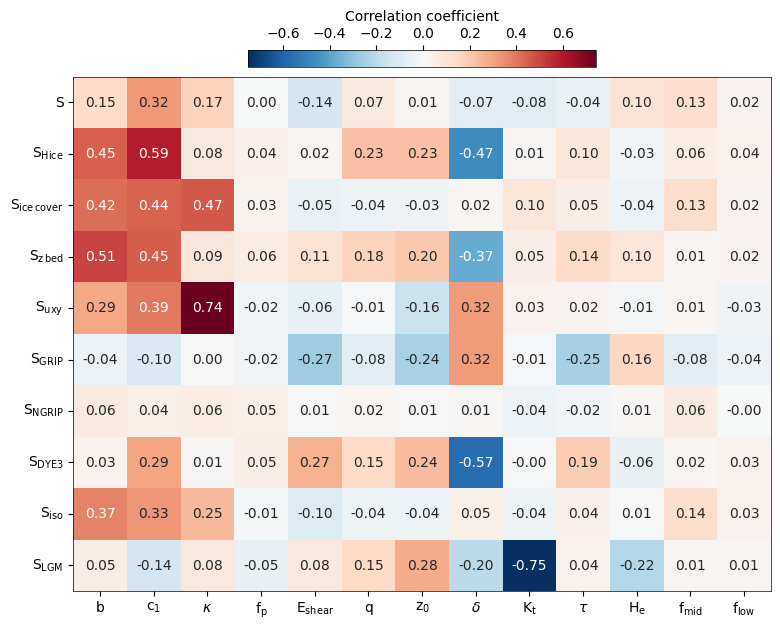

In [5]:
df_all = pd.concat([param.to_dataframe(), scores.to_dataframe()], axis=1)
corr_matrix = df_all.corr().loc[list(param.data_vars), list(scores.data_vars)]

plt.figure(figsize=(9, 8))
ax = sns.heatmap(np.transpose(corr_matrix), 
                 annot=True, fmt='.2f',
                 cmap='RdBu_r', 
                 center=0,
                 cbar_kws={'label': 'Correlation coefficient', 
                           'location': 'top', # Puede ser 'top', 'bottom', 'left'
                           'shrink': 0.5,
                           'pad': 0.015})      # Cambia el tamaño (0.8 = 80% del alto)

new_xticklabels = [param_names.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
new_yticklabels = [scores_names.get(label.get_text(), label.get_text()) for label in ax.get_yticklabels()]

ax.set_xticklabels(new_xticklabels, rotation=0, ha='center')
ax.set_yticklabels(new_yticklabels, rotation=0)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_edgecolor('black')
    
cbar = ax.collections[0].colorbar
cbar.outline.set_edgecolor('black') 
cbar.outline.set_linewidth(0.5)

plt.savefig("../figs_final/fig12_correlations.png", dpi=300, bbox_inches='tight')
